In [71]:
import copy
import itertools

import torch
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset

from contrastive_utils import (
    DomainDiscriminator,
    batch_centroid_alignment_loss,
    domain_confusion_loss,
    ordinal_logits_to_label,
    ordinal_regression_loss,
    pairwise_infonce_loss,
    ratio_kl_loss,
)
from models import SourceEncoder, TargetEncoder
from checkpoint_utils import (
    build_preprocess_info,
    capture_rng_state,
    load_dual_encoder_checkpoint,
    make_torch_generator,
    save_dual_encoder_checkpoint,
    set_reproducible_mode,
)

SEED = 42
DETERMINISTIC = True
set_reproducible_mode(SEED, deterministic=DETERMINISTIC)


In [72]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, silhouette_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [73]:
categorical_cols = [
    'OCCAT1', 'OCCAT2', 'INDCAT', 'LF', 'HOUSECL', 'EDCL', 'EDUC',
    'AGECL', 'LIFECL', 'FAMSTRUCT', 'KIDS', 'MARRIED', 'EXPENSHILO', 'WSAVED',
    'SAVRES1', 'SAVRES2', 'SAVRES3', 'SAVRES4', 'SAVRES5',
    'SAVRES6', 'SAVRES7', 'SAVRES8', 'SAVRES9'
]

SPLIT = "train"  # use train for fitting; switch to test and rerun eval cells later

x_cat_tensor = torch.load(f'../dataset/processed/{SPLIT}_x_cat_tensor.pt')
x_ratio_tensor = torch.load(f'../dataset/processed/{SPLIT}_x_ratio_tensor.pt')
labels_tensor = torch.load(f'../dataset/processed/{SPLIT}_labels_tensor.pt')

current_categorical_cardinalities = torch.load(f'../dataset/processed/{SPLIT}_cardinalities.pt').tolist()
categorical_cardinalities = torch.load(f'../dataset/processed/{SPLIT}_cardinalities.pt').tolist()

print(x_cat_tensor.shape, x_ratio_tensor.shape, labels_tensor.shape)
print('current split cardinalities:', current_categorical_cardinalities)
print('train cardinalities:        ', categorical_cardinalities)


torch.Size([13207, 23]) torch.Size([13207, 4]) torch.Size([13207])
current split cardinalities: [5, 5, 5, 2, 3, 5, 15, 7, 7, 6, 11, 3, 4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2]
train cardinalities:         [5, 5, 5, 2, 3, 5, 15, 7, 7, 6, 11, 3, 4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2]


In [74]:
# Define PyTorch DataLoader
class UserDataset(Dataset):
    def __init__(self, x_cat_tensor, x_ratio_tensor, labels_tensor):
        self.x_cat = x_cat_tensor
        self.x_ratio = x_ratio_tensor
        self.labels = labels_tensor
        
    def __len__(self):
        return len(self.x_cat)
        
    def __getitem__(self, idx):
        # 비금융 데이터, 금융 데이터, 5단계 라벨을 함께 반환
        return self.x_cat[idx], self.x_ratio[idx], self.labels[idx]

#### Run for training only

In [75]:
# Create dataset once. Train/validation split is built inside the training loop.
dataset = UserDataset(x_cat_tensor, x_ratio_tensor, labels_tensor)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

NUM_RISK_LEVELS = 5
PROJECTION_DIM = 64
RATIO_DIM = x_ratio_tensor.shape[1]

LOSS_WEIGHTS = {
    'contrastive': 1.0,
    'source_risk': 0.7,
    'target_risk': 0.3,
    'source_ratio': 1.0,
    'target_ratio': 0.4,
    'centroid': 0.3,
    'domain': 0.1,
}


def total_alignment_loss(source_output, target_output, batch_x_ratio, batch_labels, domain_discriminator, temperature, domain_lambda):
    loss_contrastive = pairwise_infonce_loss(
        source_output.embedding,
        target_output.embedding,
        temperature=temperature,
    )
    loss_source_risk = ordinal_regression_loss(
        source_output.risk_logits,
        batch_labels,
        num_risk_levels=NUM_RISK_LEVELS,
    )
    loss_target_risk = ordinal_regression_loss(
        target_output.risk_logits,
        batch_labels,
        num_risk_levels=NUM_RISK_LEVELS,
    )
    loss_source_ratio = ratio_kl_loss(source_output.ratio_logits, batch_x_ratio)
    loss_target_ratio = ratio_kl_loss(target_output.ratio_logits, batch_x_ratio)
    loss_centroid = batch_centroid_alignment_loss(
        source_output.embedding,
        target_output.embedding,
        batch_labels,
        num_risk_levels=NUM_RISK_LEVELS,
    )
    loss_domain, domain_acc = domain_confusion_loss(
        domain_discriminator,
        source_output.embedding,
        target_output.embedding,
        lambda_weight=domain_lambda,
    )

    total_loss = (
        LOSS_WEIGHTS['contrastive'] * loss_contrastive
        + LOSS_WEIGHTS['source_risk'] * loss_source_risk
        + LOSS_WEIGHTS['target_risk'] * loss_target_risk
        + LOSS_WEIGHTS['source_ratio'] * loss_source_ratio
        + LOSS_WEIGHTS['target_ratio'] * loss_target_ratio
        + LOSS_WEIGHTS['centroid'] * loss_centroid
        + LOSS_WEIGHTS['domain'] * loss_domain
    )

    metrics = {
        'total': float(total_loss.detach().item()),
        'contrastive': float(loss_contrastive.detach().item()),
        'source_risk': float(loss_source_risk.detach().item()),
        'target_risk': float(loss_target_risk.detach().item()),
        'source_ratio': float(loss_source_ratio.detach().item()),
        'target_ratio': float(loss_target_ratio.detach().item()),
        'centroid': float(loss_centroid.detach().item()),
        'domain': float(loss_domain.detach().item()),
        'domain_acc': float(domain_acc.detach().item()),
    }
    return total_loss, metrics


def evaluate_source_validation_metrics(source_encoder, val_dataloader, device):
    source_encoder.eval()

    total_abs_error = 0.0
    total_examples = 0
    correct_risk = 0

    with torch.no_grad():
        for batch_x_cat, batch_x_ratio, batch_labels in val_dataloader:
            batch_x_cat = batch_x_cat.to(device)
            batch_x_ratio = batch_x_ratio.to(device)
            batch_labels = batch_labels.to(device)

            source_output = source_encoder(batch_x_cat)
            predicted_ratio = source_output.ratio_probs
            predicted_risk = ordinal_logits_to_label(source_output.risk_logits)

            batch_size = batch_x_cat.size(0)
            total_abs_error += torch.abs(predicted_ratio - batch_x_ratio).sum().item()
            total_examples += batch_size * batch_x_ratio.size(1)
            correct_risk += (predicted_risk == batch_labels).sum().item()

    source_ratio_mae = total_abs_error / total_examples
    source_risk_acc = correct_risk / len(val_dataloader.dataset)
    return {
        'source_ratio_mae': float(source_ratio_mae),
        'source_risk_acc': float(source_risk_acc),
    }


In [77]:
# Hyperparameters and early stopping

param_grid = {
    'batch_size': [256],
    'learning_rate': [1e-3],
    'temperature': [0.2],
    'output_dim': [256],
    'epochs': [200],
}

PATIENCE = 20
MIN_DELTA = 0.0005
DOMAIN_WARMUP_EPOCHS = 20
VALIDATION_RATIO = 0.1

keys = param_grid.keys()
values = param_grid.values()
combinations = list(itertools.product(*values))

print(f"search combos: {len(combinations)} (device={device})")
print(f"early stop metric: validation source_ratio_MAE, patience={PATIENCE}, min_delta={MIN_DELTA}\n")
print('loss weights:', LOSS_WEIGHTS)

best_overall_val_source_ratio_mae = float('inf')
best_params = None
training_preprocess_info = build_preprocess_info(
    categorical_cols=categorical_cols,
    categorical_cardinalities=categorical_cardinalities,
    x_cat_tensor=x_cat_tensor,
    x_ratio_tensor=x_ratio_tensor,
    labels_tensor=labels_tensor,
    split=SPLIT,
)

all_indices = np.arange(len(labels_tensor))
train_indices, val_indices = train_test_split(
    all_indices,
    test_size=VALIDATION_RATIO,
    random_state=SEED,
    shuffle=True,
    stratify=labels_tensor.numpy(),
)
train_dataset = Subset(dataset, train_indices.tolist())
val_dataset = Subset(dataset, val_indices.tolist())
print(f'train examples: {len(train_dataset)}, validation examples: {len(val_dataset)}')

for idx, (batch_size, lr, temp, out_dim, num_epochs) in enumerate(combinations):
    print(f"[{idx+1}/{len(combinations)}] split={SPLIT}, batch={batch_size}, lr={lr}, temp={temp}, dim={out_dim}, epochs={num_epochs}")

    combo_seed = SEED + idx
    train_dataloader_generator = make_torch_generator(combo_seed)
    train_dataloader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=train_dataloader_generator,
    )
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    source_encoder = SourceEncoder(
        categorical_cardinalities,
        embed_dim=16,
        output_dim=out_dim,
        projection_dim=PROJECTION_DIM,
        num_risk_levels=NUM_RISK_LEVELS,
        ratio_dim=RATIO_DIM,
    ).to(device)
    target_encoder = TargetEncoder(
        input_dim=RATIO_DIM,
        output_dim=out_dim,
        projection_dim=PROJECTION_DIM,
        num_risk_levels=NUM_RISK_LEVELS,
        ratio_dim=RATIO_DIM,
    ).to(device)
    domain_discriminator = DomainDiscriminator(input_dim=PROJECTION_DIM).to(device)

    optimizer = optim.Adam(
        list(source_encoder.parameters())
        + list(target_encoder.parameters())
        + list(domain_discriminator.parameters()),
        lr=lr,
    )

    best_epoch_val_source_ratio_mae = float('inf')
    best_epoch_index = -1
    best_source_state = None
    best_target_state = None
    epochs_no_improve = 0
    final_val_metrics = None
    best_epoch_val_metrics = None

    for epoch in range(num_epochs):
        source_encoder.train()
        target_encoder.train()
        domain_discriminator.train()

        domain_lambda = min(1.0, float(epoch + 1) / DOMAIN_WARMUP_EPOCHS)
        running = {
            'total': 0.0,
            'contrastive': 0.0,
            'source_risk': 0.0,
            'target_risk': 0.0,
            'source_ratio': 0.0,
            'target_ratio': 0.0,
            'centroid': 0.0,
            'domain': 0.0,
            'domain_acc': 0.0,
        }

        for batch_x_cat, batch_x_ratio, batch_labels in train_dataloader:
            batch_x_cat = batch_x_cat.to(device)
            batch_x_ratio = batch_x_ratio.to(device)
            batch_labels = batch_labels.to(device)

            optimizer.zero_grad(set_to_none=True)

            source_output = source_encoder(batch_x_cat)
            target_output = target_encoder(batch_x_ratio)

            total_loss, metrics = total_alignment_loss(
                source_output,
                target_output,
                batch_x_ratio,
                batch_labels,
                domain_discriminator,
                temperature=temp,
                domain_lambda=domain_lambda,
            )

            total_loss.backward()
            optimizer.step()

            for key, value in metrics.items():
                running[key] += value

        avg_metrics = {key: value / len(train_dataloader) for key, value in running.items()}
        val_metrics = evaluate_source_validation_metrics(source_encoder, val_dataloader, device)
        final_val_metrics = val_metrics

        current_val_source_ratio_mae = val_metrics['source_ratio_mae']
        if current_val_source_ratio_mae < best_epoch_val_source_ratio_mae - MIN_DELTA:
            best_epoch_val_source_ratio_mae = current_val_source_ratio_mae
            best_epoch_index = epoch + 1
            epochs_no_improve = 0
            best_source_state = copy.deepcopy(source_encoder.state_dict())
            best_target_state = copy.deepcopy(target_encoder.state_dict())
            best_epoch_val_metrics = dict(val_metrics)
        else:
            epochs_no_improve += 1

        if (epoch + 1) % 10 == 0:
            print(
                f"  - epoch [{epoch+1}/{num_epochs}] "
                f"train_total={avg_metrics['total']:.4f}, "
                f"pair={avg_metrics['contrastive']:.4f}, "
                f"src_risk={avg_metrics['source_risk']:.4f}, "
                f"src_ratio={avg_metrics['source_ratio']:.4f}, "
                f"domain_acc={avg_metrics['domain_acc']:.4f}, "
                f"val_src_ratio_mae={val_metrics['source_ratio_mae']:.4f}, "
                f"val_src_risk_acc={val_metrics['source_risk_acc']:.4f}, "
                f"lambda={domain_lambda:.2f}, "
                f"no_improve={epochs_no_improve}/{PATIENCE}"
            )

        if epochs_no_improve >= PATIENCE:
            print(f"  Early stopping at epoch {epoch+1} (best epoch: {best_epoch_index})")
            break

    if best_source_state is not None:
        source_encoder.load_state_dict(best_source_state)
        target_encoder.load_state_dict(best_target_state)

    if best_epoch_val_source_ratio_mae < best_overall_val_source_ratio_mae:
        best_overall_val_source_ratio_mae = best_epoch_val_source_ratio_mae
        best_params = {
            'batch_size': batch_size,
            'learning_rate': lr,
            'temperature': temp,
            'output_dim': out_dim,
            'projection_dim': PROJECTION_DIM,
            'epochs_run': best_epoch_index,
            'seed': SEED,
            'dataloader_seed': combo_seed,
            'validation_ratio': VALIDATION_RATIO,
            'early_stopping_metric': 'val_source_ratio_mae',
            'best_val_source_ratio_mae': best_epoch_val_source_ratio_mae,
            'best_val_source_risk_acc': best_epoch_val_metrics['source_risk_acc'] if best_epoch_val_metrics is not None else None,
            'loss_weights': LOSS_WEIGHTS,
            'domain_warmup_epochs': DOMAIN_WARMUP_EPOCHS,
        }
        print(f"  new best validation source_ratio_MAE: {best_overall_val_source_ratio_mae:.4f}\n")

        save_dual_encoder_checkpoint(
            checkpoint_dir='../checkpoints',
            source_encoder=source_encoder,
            target_encoder=target_encoder,
            preprocess_info=training_preprocess_info,
            model_config={
                'embed_dim': 16,
                'output_dim': out_dim,
                'projection_dim': PROJECTION_DIM,
                'num_risk_levels': NUM_RISK_LEVELS,
                'ratio_dim': RATIO_DIM,
                'target_input_dim': x_ratio_tensor.shape[1],
            },
            best_params=best_params,
            best_loss=best_overall_val_source_ratio_mae,
            optimizer=optimizer,
            epoch=best_epoch_index,
            rng_state=capture_rng_state(dataloader_generator=train_dataloader_generator),
            seed=SEED,
            deterministic=DETERMINISTIC,
        )
        print('saved checkpoint metadata: ../checkpoints/best_checkpoint_meta.json')
    else:
        print('')

print('grid search done')
print(f'best validation source_ratio_MAE: {best_overall_val_source_ratio_mae:.4f}')
print(f'best params: {best_params}')


search combos: 1 (device=cpu)
early stop metric: validation source_ratio_MAE, patience=20, min_delta=0.0005

loss weights: {'contrastive': 1.0, 'source_risk': 1.5, 'target_risk': 0.3, 'source_ratio': 2.0, 'target_ratio': 0.4, 'centroid': 0.3, 'domain': 0.05}
train examples: 11886, validation examples: 1321
[1/1] split=train, batch=256, lr=0.001, temp=0.2, dim=256, epochs=200
  - epoch [10/200] train_total=6.9529, pair=5.2072, src_risk=0.5168, src_ratio=0.4467, domain_acc=0.7262, val_src_ratio_mae=0.1788, val_src_risk_acc=0.3278, lambda=0.50, no_improve=3/20
  - epoch [20/200] train_total=6.8138, pair=5.1283, src_risk=0.5039, src_ratio=0.4261, domain_acc=0.7003, val_src_ratio_mae=0.1805, val_src_risk_acc=0.3369, lambda=1.00, no_improve=13/20
  Early stopping at epoch 27 (best epoch: 7)
  new best validation source_ratio_MAE: 0.1773

saved checkpoint metadata: ../checkpoints/best_checkpoint_meta.json
grid search done
best validation source_ratio_MAE: 0.1773
best params: {'batch_size': 25

#### Load checkpoints

In [78]:
dataset = UserDataset(x_cat_tensor, x_ratio_tensor, labels_tensor)
dataloader = DataLoader(dataset, batch_size=512, shuffle=False)

In [79]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

try:
    source_encoder, target_encoder, checkpoint_meta, validation = load_dual_encoder_checkpoint(
        checkpoint_dir='../checkpoints',
        device=device,
        current_categorical_cols=categorical_cols,
        current_categorical_cardinalities=current_categorical_cardinalities,
        current_x_cat_tensor=x_cat_tensor,
        current_x_ratio_tensor=x_ratio_tensor,
        current_labels_tensor=labels_tensor,
        current_split=SPLIT,
        strict=True,
    )
    print('checkpoint loaded')
    print('saved model config:', checkpoint_meta['model_config'])
    for warning in validation['warnings']:
        print('warning:', warning)
except Exception as exc:
    print('a new checkpoint is required for the updated pair-InfoNCE training setup.')
    print('run the training cells first, then come back to evaluation.')
    raise exc


checkpoint loaded
saved model config: {'embed_dim': 16, 'output_dim': 256, 'projection_dim': 64, 'num_risk_levels': 5, 'ratio_dim': 4, 'target_input_dim': 4}


In [ ]:
all_h_NF, all_z_NF = [], []
all_h_F, all_z_F = [], []
all_labels = []
all_true_ratio = []
all_source_risk_pred, all_target_risk_pred = [], []
all_source_ratio_pred, all_target_ratio_pred = [], []

with torch.no_grad():
    for batch_x_cat, batch_x_ratio, batch_labels in dataloader:
        batch_x_cat = batch_x_cat.to(device)
        batch_x_ratio = batch_x_ratio.to(device)

        source_output = source_encoder(batch_x_cat)
        target_output = target_encoder(batch_x_ratio)

        all_h_NF.append(source_output.hidden.cpu())
        all_z_NF.append(source_output.embedding.cpu())
        all_h_F.append(target_output.hidden.cpu())
        all_z_F.append(target_output.embedding.cpu())
        all_labels.append(batch_labels.cpu())
        all_true_ratio.append(batch_x_ratio.cpu())
        all_source_risk_pred.append(ordinal_logits_to_label(source_output.risk_logits).cpu())
        all_target_risk_pred.append(ordinal_logits_to_label(target_output.risk_logits).cpu())
        all_source_ratio_pred.append(source_output.ratio_probs.cpu())
        all_target_ratio_pred.append(target_output.ratio_probs.cpu())

all_h_NF = torch.cat(all_h_NF, dim=0)
all_z_NF = torch.cat(all_z_NF, dim=0)
all_h_F = torch.cat(all_h_F, dim=0)
all_z_F = torch.cat(all_z_F, dim=0)
all_labels = torch.cat(all_labels, dim=0)
all_true_ratio = torch.cat(all_true_ratio, dim=0)
all_source_risk_pred = torch.cat(all_source_risk_pred, dim=0)
all_target_risk_pred = torch.cat(all_target_risk_pred, dim=0)
all_source_ratio_pred = torch.cat(all_source_ratio_pred, dim=0)
all_target_ratio_pred = torch.cat(all_target_ratio_pred, dim=0)

all_z_NF = F.normalize(all_z_NF, dim=1)
all_z_F = F.normalize(all_z_F, dim=1)


embedding extraction done: torch.Size([13207, 64]) torch.Size([13207, 64]) torch.Size([13207])
source direct risk acc: 0.3642
target direct risk acc: 0.8043
source ratio MAE: 0.1726
target ratio MAE: 0.0095


#### Alignment 정량 평가

In [ ]:
source_risk_acc = (all_source_risk_pred == all_labels).float().mean().item()
target_risk_acc = (all_target_risk_pred == all_labels).float().mean().item()
source_ratio_mae = torch.mean(torch.abs(all_source_ratio_pred - all_true_ratio)).item()
target_ratio_mae = torch.mean(torch.abs(all_target_ratio_pred - all_true_ratio)).item()

print('embedding extraction done:', all_z_NF.shape, all_z_F.shape, all_labels.shape)
print(f'source direct risk acc: {source_risk_acc:.4f}')
print(f'target direct risk acc: {target_risk_acc:.4f}')
print(f'source ratio MAE: {source_ratio_mae:.4f}')
print(f'target ratio MAE: {target_ratio_mae:.4f}')

In [81]:
z_nf_np = all_z_NF.numpy()
z_f_np = all_z_F.numpy()
labels_np = all_labels.numpy()

concat_z = np.concatenate([z_nf_np, z_f_np], axis=0)
concat_risk = np.concatenate([labels_np, labels_np], axis=0)
concat_modality = np.array([0] * len(z_nf_np) + [1] * len(z_f_np))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_linear_probe(X, y, *, scale=False):
    clf = LogisticRegression(max_iter=5000)
    if scale:
        clf = make_pipeline(StandardScaler(), clf)

    acc_scores, f1_scores = [], []
    for train_idx, test_idx in cv.split(X, y):
        model = clone(clf)
        model.fit(X[train_idx], y[train_idx])
        pred = model.predict(X[test_idx])
        acc_scores.append(accuracy_score(y[test_idx], pred))
        f1_scores.append(f1_score(y[test_idx], pred, average='macro'))

    return {
        'accuracy_mean': float(np.mean(acc_scores)),
        'accuracy_std': float(np.std(acc_scores)),
        'macro_f1_mean': float(np.mean(f1_scores)),
        'macro_f1_std': float(np.std(f1_scores)),
    }

def domain_classifier_score(X, y):
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
    scores = []
    for train_idx, test_idx in cv.split(X, y):
        model = clone(clf)
        model.fit(X[train_idx], y[train_idx])
        pred = model.predict(X[test_idx])
        scores.append(accuracy_score(y[test_idx], pred))

    return {
        'accuracy_mean': float(np.mean(scores)),
        'accuracy_std': float(np.std(scores)),
    }

def cross_modal_retrieval(src, tgt, src_labels, tgt_labels, ks=(1, 5)):
    sim = src @ tgt.T
    order = np.argsort(-sim, axis=1)
    ranked_labels = tgt_labels[order]
    matches = ranked_labels == src_labels[:, None]
    first_hit = np.argmax(matches, axis=1)
    has_hit = matches.any(axis=1)

    metrics = {}
    for k in ks:
        metrics[f'recall@{k}'] = float(matches[:, :k].any(axis=1).mean())

    reciprocal_rank = np.where(has_hit, 1.0 / (first_hit + 1), 0.0)
    metrics['mrr'] = float(reciprocal_rank.mean())
    return metrics

def centroid_distance_by_class(src, tgt, labels):
    rows = []
    for cls in np.unique(labels):
        src_centroid = src[labels == cls].mean(axis=0)
        tgt_centroid = tgt[labels == cls].mean(axis=0)
        euclidean = np.linalg.norm(src_centroid - tgt_centroid)
        cosine = 1 - np.dot(src_centroid, tgt_centroid) / (
            np.linalg.norm(src_centroid) * np.linalg.norm(tgt_centroid)
        )
        rows.append({
            'risk_label': int(cls),
            'euclidean_distance': float(euclidean),
            'cosine_distance': float(cosine),
        })
    return pd.DataFrame(rows).sort_values('risk_label').reset_index(drop=True)

retrieval_s2t = cross_modal_retrieval(z_nf_np, z_f_np, labels_np, labels_np)
retrieval_t2s = cross_modal_retrieval(z_f_np, z_nf_np, labels_np, labels_np)

retrieval_df = pd.DataFrame([
    {'direction': 'source_to_target', **retrieval_s2t},
    {'direction': 'target_to_source', **retrieval_t2s},
    {
        'direction': 'bidirectional_mean',
        'recall@1': float(np.mean([retrieval_s2t['recall@1'], retrieval_t2s['recall@1']])),
        'recall@5': float(np.mean([retrieval_s2t['recall@5'], retrieval_t2s['recall@5']])),
        'mrr': float(np.mean([retrieval_s2t['mrr'], retrieval_t2s['mrr']])),
    },
])

centroid_df = centroid_distance_by_class(z_nf_np, z_f_np, labels_np)
silhouette_results = pd.DataFrame([
    {
        'label_type': 'risk_label',
        'silhouette_cosine': float(silhouette_score(concat_z, concat_risk, metric='cosine')),
    },
    {
        'label_type': 'modality',
        'silhouette_cosine': float(silhouette_score(concat_z, concat_modality, metric='cosine')),
    },
])

domain_results = pd.DataFrame([domain_classifier_score(concat_z, concat_modality)])
source_probe_df = pd.DataFrame([evaluate_linear_probe(z_nf_np, labels_np)])
target_probe_df = pd.DataFrame([evaluate_linear_probe(z_f_np, labels_np)])

print('1. Cross-modal retrieval')
display(retrieval_df.round(4))

print('2. Class-wise centroid distance (source vs target)')
display(centroid_df.round(4))
print('mean euclidean distance:', round(float(centroid_df['euclidean_distance'].mean()), 4))
print('mean cosine distance:', round(float(centroid_df['cosine_distance'].mean()), 4))

print('3. Silhouette score')
display(silhouette_results.round(4))
print('  - risk_label silhouette는 높을수록 좋음')
print('  - modality silhouette는 낮을수록 source/target 정렬이 잘 된 것')

print('4. Domain classifier accuracy (source vs target)')
display(domain_results.round(4))
print('  - 0.5에 가까울수록 modality 구분이 어려워 alignment 관점에서 유리')

print('5. Linear probe on risk label')
probe_results = pd.concat([
    source_probe_df.assign(embedding='source'),
    target_probe_df.assign(embedding='target'),
], ignore_index=True)
display(probe_results[['embedding', 'accuracy_mean', 'accuracy_std', 'macro_f1_mean', 'macro_f1_std']].round(4))
print('  - source probe가 target probe와 가까워질수록 risk semantic transfer가 잘 된 것')


1. Cross-modal retrieval


,direction,recall@1,recall@5,mrr
0,source_to_target,0.3559,0.5020,0.4265
1,target_to_source,0.5353,0.8811,0.6815
2,bidirectional_mean,0.4456,0.6916,0.5540


2. Class-wise centroid distance (source vs target)


,risk_label,euclidean_distance,cosine_distance
0,0,0.5480,0.2061
1,1,0.5038,0.2023
2,2,0.4990,0.1974
3,3,0.4935,0.1878
4,4,0.5428,0.2162


mean euclidean distance: 0.5174
mean cosine distance: 0.2019
3. Silhouette score


...

  - risk_label silhouette는 높을수록 좋음
  - modality silhouette는 낮을수록 source/target 정렬이 잘 된 것
4. Domain classifier accuracy (source vs target)


,accuracy_mean,accuracy_std
0,1.0,0.0


  - 0.5에 가까울수록 modality 구분이 어려워 alignment 관점에서 유리
5. Linear probe on risk label


,embedding,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std
0,source,0.4061,0.0031,0.2925,0.0045
1,target,0.7872,0.0072,0.7413,0.0091


  - source probe가 target probe와 가까워질수록 risk semantic transfer가 잘 된 것


#### 시각화 및 유사도 검증

In [82]:
# 유사도 검증

sim_matrix = all_z_NF @ all_z_F.T

diag_sim = sim_matrix.diag().mean().item()

label_mask = all_labels[:, None] == all_labels[None, :]
same_label_sim = sim_matrix[label_mask].mean().item()
diff_label_sim = sim_matrix[~label_mask].mean().item()

top1_idx = sim_matrix.argmax(dim=1)
top1_label_acc = (all_labels[top1_idx] == all_labels).float().mean().item()

print(f"같은 샘플(source-target) 평균 유사도: {diag_sim:.4f}")
print(f"같은 라벨 평균 유사도: {same_label_sim:.4f}")
print(f"다른 라벨 평균 유사도: {diff_label_sim:.4f}")
print(f"Top-1 라벨 검색 정확도: {top1_label_acc:.4f}")

같은 샘플(source-target) 평균 유사도: 0.6045
같은 라벨 평균 유사도: 0.5330
다른 라벨 평균 유사도: 0.4282
Top-1 라벨 검색 정확도: 0.3561


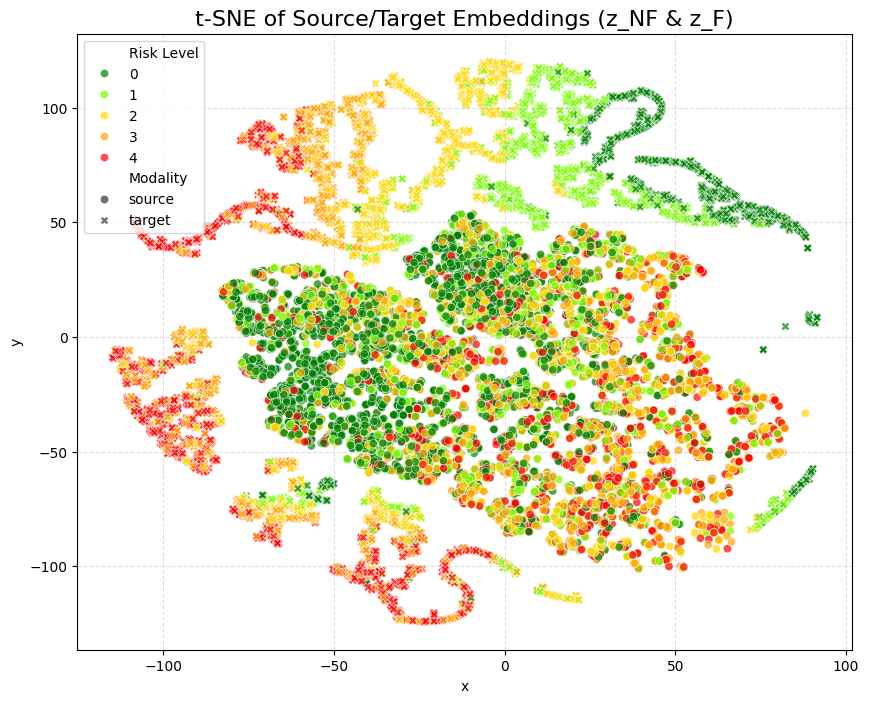

In [83]:
# t-SNE 시각화

emb = torch.cat([all_z_NF, all_z_F], dim=0).numpy()
modality = ['source'] * len(all_z_NF) + ['target'] * len(all_z_F)
risk = np.concatenate([all_labels.numpy(), all_labels.numpy()])

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb_2d = tsne.fit_transform(emb)

df = pd.DataFrame({
    'x': emb_2d[:, 0],
    'y': emb_2d[:, 1],
    'Risk Level': risk,
    'Modality': modality,
})

risk_palette = {
    0: '#008000',
    1: '#7CFC00',
    2: '#FFD700',
    3: '#FFA500',
    4: '#FF0000',
}

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='x', y='y', hue='Risk Level', style='Modality', hue_order=[0, 1, 2, 3, 4], palette=risk_palette, alpha=0.7)
plt.title("t-SNE of Source/Target Embeddings (z_NF & z_F)", fontsize=16)
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

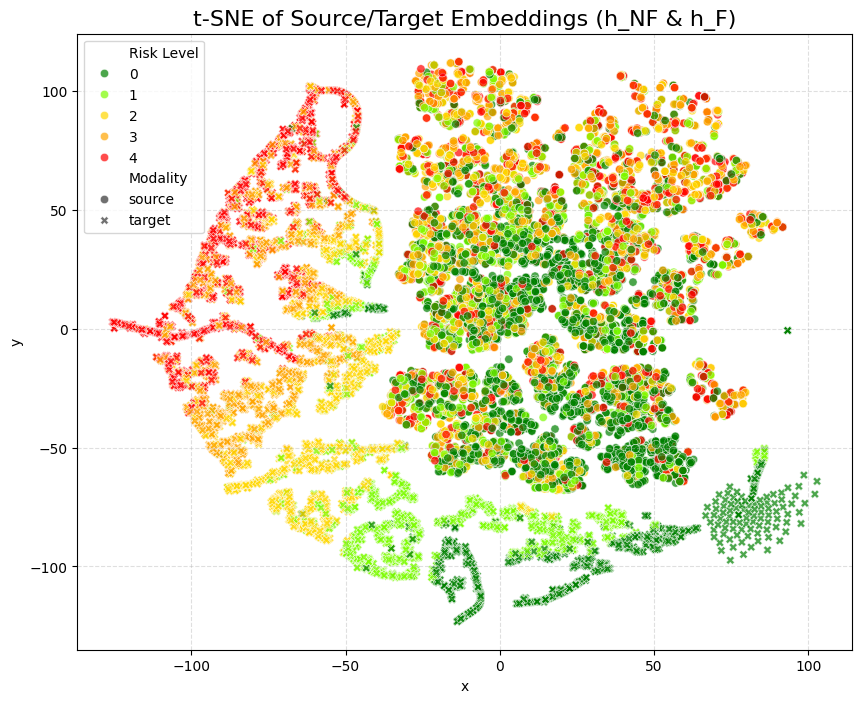

In [84]:
emb = torch.cat([all_h_NF, all_h_F], dim=0).numpy()
modality = ['source'] * len(all_h_NF) + ['target'] * len(all_h_F)
risk = np.concatenate([all_labels.numpy(), all_labels.numpy()])

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb_2d = tsne.fit_transform(emb)

df = pd.DataFrame({
    'x': emb_2d[:, 0],
    'y': emb_2d[:, 1],
    'Risk Level': risk,
    'Modality': modality,
})

risk_palette = {
    0: '#008000',
    1: '#7CFC00',
    2: '#FFD700',
    3: '#FFA500',
    4: '#FF0000',
}

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='x', y='y', hue='Risk Level', style='Modality', hue_order=[0, 1, 2, 3, 4], palette=risk_palette, alpha=0.7)
plt.title("t-SNE of Source/Target Embeddings (h_NF & h_F)", fontsize=16)
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()